# Notebook 3 - Human-in-the-loop vs. autonomous vs. stigmergic control

**Project:** Real Autonomy in Autonomous Haulage · *Digital-twin experiments*
**Site (anonymised):** *Mine A*, open-pit copper mine, *Region R* · **Operator (anonymised):** *Company X*
**Runtime:** Google Colab (CPU is enough) · **Dependencies:** `numpy`, `pandas`, `matplotlib` (pre-installed in Colab)

> **Central question.** Who should close the control loop of an autonomous haulage system - a human dispatcher, a human approving an optimiser, a human supervising an autonomous optimiser, a fully autonomous central optimiser, or a decentralised coordination layer with no central node - and how does each behave in a normal shift and under stress?

**Five governance modes** (same trucks, same mine, same random-event *generator*; only who decides and who clears exceptions changes - see the caveat in Section 1 on what else changes alongside that)

| # | Mode | Dispatch decision | Exceptions (A-stops) | Depends on central FMS? |
|---|---|---|---|---|
| 1 | Human-only | Human on the radio, 6-min-old picture, noisy, absent at breaks | Human, 6 min | No (radio) |
| 2 | Human-**in**-the-loop | Optimiser proposes, human **approves each assignment** (~1.5 min, 8 % veto, timeout at breaks) | Human, 6 min | Yes |
| 3 | Human-**on**-the-loop | Optimiser executes automatically, human supervises | Human, 6 min (+ breaks) | Yes |
| 4 | Autonomous, central | Optimiser, no human | Field crew, 18 min | Yes |
| 5 | Stigmergic-inspired heuristic | Evaporating cost/footprint marks per shovel, softmax choice, no approval step | Peer-assisted, 12 min | No |

Mode 5 was called "autopoietic" in earlier drafts of this project. That name is dropped here: the mechanism implemented is stigmergic coordination through evaporating marks, not self-production of organisation in the biological sense, and Section 1 spells out exactly what it does and does not decentralise.

**Four scenarios:** *Normal shift* · *FMS/network outage* 120 min · *Shovel SH-2 failure* 120 min · *Compound* (both at once).

## 0. Contents
1. Concepts and assumptions
2. Simulator and governance-mode code
3. Experiment: 5 modes × 4 scenarios
4. Resilience, human workload and time series
5. Sensitivity to the assumptions that favour or penalise humans / autonomy
6. Interpretation, limitations, next steps
7. References

## 1. Concepts and assumptions
**Levels of automation.** Human involvement can be placed on a scale from full manual to full autonomy [PSW]. *In-the-loop* means the human is inside every decision cycle (latency, availability, attention); *on-the-loop* means the human supervises and intervenes on exceptions. Bainbridge's "ironies of automation" warns that the operator left with only the exceptions is the least prepared for them [BAIN], and the out-of-the-loop literature shows slower recovery when humans re-enter [ENDS].

**What mode 5 actually is.** Biological autopoiesis refers to a system that continuously produces and repairs its own organisation [MV]; this notebook does not model that. What it implements is narrower: agents coordinate through marks left in a shared array - an evaporating cost/footprint estimate per shovel, incremented by every dispatch and by every redirect away from a failed shovel - in the spirit of stigmergic coordination in insect colonies [GRASSE][BDT][DORIGO]. It is called the **stigmergic-inspired heuristic** for that reason. It is important to be precise about what is, and is not, decentralised here: every truck reads and writes the *same* shared arrays (`bias`, the dispatch log), instantly and without noise. There is no per-truck local sensing radius and no communication delay between the mark being left and it being seen by the next truck. So the mechanism is decentralised in *authority* (no human or optimiser approves each move) but centralised in *information* (all trucks share one global, synchronous state). Section 4 revisits this distinction when interpreting the failure-recovery results.

**Human availability.** Two 30-min breaks (minutes 240–270 and 480–510). During them, mode 1 follows the static plan, mode 2 auto-accepts after 5 min, mode 3 leaves A-stops waiting.

**Central outage.** Centralised modes (2, 3, 4) hold trucks (TUM 4060) and after 10 min fall back to the static plan; trucks queued at a dead shovel cannot be redirected until the FMS returns. The stigmergic-inspired heuristic does not query the FMS at any point in its decision code, so an FMS/network outage cannot affect it by construction - that is a fact about which state variables the mode reads, not a demonstrated resilience property; Section 4 separates the two.

**Approval latency, veto rate, crew response times (6/12/18 min) and the softmax temperature are engineering assumptions, not measurements**; Section 5 varies them. The comparison answers "under these assumptions, what is the trade-off?", not "which mode is best in general".

## 2. Simulator and governance-mode code

In [1]:
import numpy as np, pandas as pd, math
from scipy.stats import t as student_t
try:
    from IPython.display import display
except ImportError:          # plain-python fallback
    display = print
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
from collections import deque
from dataclasses import dataclass, replace

# ---------------------------------------------------------------- state ids
TE, QS, SS, WL, LD, TF, QK, SK, WD, DP, DN, RF, HD, E70, E110, E60, PD = range(17)
PHASES = ["Travelling Empty", "Queuing At Source", "Spotting At Source", "Wait for load", "Loading",
          "Travelling Full", "Queuing at sink", "Spotting at sink", "Wait for Dump", "Dumping"]
SLOT_NAME = PHASES + ["Breakdown (5000)", "Refuel (2020)", "Hold: wait dispatch/approval (4060/4150)",
                      "Obstacle / interaction stop (4070)", "Emergency A-stop (4110)", "Autonomy HW event (5060)", "Process delays (2xxx/4xxx)"]
SLOT_CODE = [1010, 7010, 1010, 7000, 1010, 1010, 7020, 1010, 7000, 1010, 5000, 2020, 4060, 4070, 4110, 5060, 4000]
QUEUE_SLOTS = (QS, QK)              # non value-adding queues (TUM 7010 / 7020)
DOWN_SLOTS = (DN, E60)              # equipment downtime (TUM 5xxx)
CYCLE_SLOTS = list(range(10))

# Reference values read from the (anonymised) operations dashboard, 8-16 Mar window
REF = {"Travelling Empty": 9.90, "Queuing At Source": 6.06, "Spotting At Source": 1.03, "Wait for load": 1.24,
       "Loading": 2.42, "Travelling Full": 9.14, "Queuing at sink": 1.56, "Spotting at sink": 0.70,
       "Wait for Dump": 0.37, "Dumping": 1.09}
REF_KPI = {"cycle_time": 33.51, "availability": 84.39, "utilization": 66.20, "tph_productive": 787.01,
           "hang_time": 2.24, "load_factor_t": 338.0}


@dataclass
class P:
    n_trucks: int = 23
    T: float = 720.0            # one 12 h shift, minutes
    warm: float = 60.0          # warm-up discarded from KPIs
    dt: float = 0.25
    payload: float = 338.0
    # per-shovel geometry (minutes) -> 5 active shovels (a 6th is out of service in the reference data)
    te: tuple = (7.0, 9.1, 10.2, 12.8, 14.4)
    tf: tuple = (6.6, 8.6, 9.6, 11.8, 13.4)
    load: tuple = (2.2, 2.4, 2.4, 2.6, 2.7)
    spot_src: float = 1.03
    wait_load: float = 1.24
    spot_sink: float = 0.70
    wait_dump: float = 0.37
    dump: float = 1.09
    sink_bays: int = 2
    sink_block_mtbf: float = 60.0   # crusher / dump-pocket blockages (min between events)
    sink_block_min: float = 7.0
    static_alloc: tuple = (9, 5, 4, 3, 2)
    cv: float = 0.25
    mtbf_h: float = 10.0
    mttr_h: float = 1.85
    shovel_mtbf_h: float = 30.0
    shovel_mttr_h: float = 1.5
    refuel_min: float = 12.0
    proc_p: float = 0.40        # prob. of a process delay (shift hand-over, lock-outs, weather...) at a decision point
    proc_mean: float = 8.0
    # interaction with heterogeneous traffic (manual / light vehicles / other autonomy stacks)
    lam_int: float = 0.020      # events per travelling minute
    comms_cov: float = 0.5      # 0 = no heterogeneous comms, 1 = full interoperability
    d_soft: float = 0.4
    d_hard: float = 3.5
    p_astop: float = 0.06       # probability that an uncoordinated hard stop escalates to an A-stop
    d_astop: float = 14.0
    lam_hw: float = 0.0015      # autonomy hardware events per travelling minute
    d_hw: float = 6.0
    handshake_gain: float = 0.0  # fraction of spot/wait-for-load time removed by full truck-shovel comms
    shovel_outages: tuple = ()  # ((shovel, start_min, end_min), ...)
    system_outages: tuple = ()  # ((start_min, end_min), ...) central FMS / network outage
    fallback_min: float = 10.0  # after this long in an outage, centralised policies fall back to the static plan
    seed: int = 0


HALF_DT = 0.125   # a timer that is decremented every dt overshoots by dt/2 on average -> compensate


def _ln(rng, mean, cv):
    s2 = math.log(1 + cv * cv)
    return max(0.02, rng.lognormal(math.log(mean) - s2 / 2, math.sqrt(s2)) - HALF_DT)


class Sim:
    def __init__(self, p: P, policy):
        self.p, self.policy = p, policy
        seed_seq = np.random.SeedSequence(p.seed)
        env_seed, policy_seed = seed_seq.spawn(2)
        self.rng = np.random.default_rng(env_seed)
        self.policy_rng = np.random.default_rng(policy_seed)
        N, M = p.n_trucks, len(p.te)
        self.N, self.M = N, M
        self.state = [TE] * N; self.left = [0.0] * N; self.tgt = [0] * N
        self.evt_left = [0.0] * N; self.evt_slot = [E70] * N
        self.hold_left = [0.0] * N; self.pending_tgt = [0] * N
        self.disp_t = [0.0] * N; self.disp_phi = [None] * N
        self.cycle_start = [0.0] * N
        self.fail_t = [self.rng.exponential(p.mtbf_h * 60) for _ in range(N)]
        self.refuel_t = [self.rng.uniform(200, 560) for _ in range(N)]
        self.acct = np.zeros((N, 17))
        self.shq = [[] for _ in range(M)]; self.occ = [-1] * M
        self.committed = [0] * M
        self.down = [False] * M
        self.sh_next_fail = [self.rng.exponential(p.shovel_mtbf_h * 60) for _ in range(M)]
        self.sh_up_at = [0.0] * M
        self.idle = np.zeros(M); self.loads = np.zeros(M); self.qtime = np.zeros(M)
        self.skq = []; self.sink_occ = 0
        self.sink_next_block = self.rng.exponential(p.sink_block_mtbf); self.sink_blocked_until = 0.0
        self.dump_times = []
        self.trips = 0; self.cycles = []; self.n_evt = {E70: 0, E110: 0, E60: 0}
        self.n_touch = 0; self.hist = []; self.dlog = deque()
        self.t = 0.0; self.k = 0
        self.home = []
        for a, n in enumerate(p.static_alloc):
            self.home += [a] * n
        self.home = (self.home + [0] * N)[:N]
        self.qdown_since = [None] * N
        self.tons_log = []
        for i in range(N):
            a = self._pick(i)
            self._depart(i, a, frac=self.rng.uniform(0.2, 1.0))

    # ------------------------------------------------------------ observation API used by policies
    def obs(self, lag):
        if lag <= 0 or not self.hist:
            return list(self.committed), list(self.down)
        idx = max(0, len(self.hist) - 1 - int(round(lag / self.p.dt)))
        return self.hist[idx]

    def recent(self, lag):
        c = [0] * self.M
        for (t, a) in self.dlog:
            if t > self.t - lag:
                c[a] += 1
        return c

    def in_outage(self):
        for (a, b) in self.p.system_outages:
            if a <= self.t < b:
                return a
        return None

    def phys_queue(self):
        return [len(q) + (1 if self.occ[a] >= 0 else 0) for a, q in enumerate(self.shq)]

    # ------------------------------------------------------------ helpers
    def _pick(self, i, redirect=False):
        a = self.policy.choose(self, i, redirect)
        self.disp_phi[i] = getattr(self.policy, "last_phi", None)
        return a

    def _depart(self, i, a, frac=1.0):
        p = self.p
        self.tgt[i] = a; self.committed[a] += 1; self.disp_t[i] = self.t
        self.dlog.append((self.t, a))
        while self.dlog and self.dlog[0][0] < self.t - 30:
            self.dlog.popleft()
        self.state[i] = TE
        self.left[i] = _ln(self.rng, p.te[a], p.cv) * frac

    def _next(self, i):
        """decision point after dumping / repair / refuel"""
        p = self.p
        if self.t >= self.fail_t[i]:
            self.state[i] = DN
            self.left[i] = _ln(self.rng, p.mttr_h * 60, 0.5)
            self.fail_t[i] = self.t + self.left[i] + self.rng.exponential(p.mtbf_h * 60)
            return
        if self.t >= self.refuel_t[i]:
            self.state[i] = RF; self.left[i] = _ln(self.rng, p.refuel_min, 0.2)
            self.refuel_t[i] = 1e9
            return
        if self.rng.random() < p.proc_p:
            self.state[i] = PD; self.left[i] = _ln(self.rng, p.proc_mean, 0.6)
            return
        self._dispatch(i)

    def _dispatch(self, i):
        p = self.p
        pol = self.policy
        if getattr(pol, "central", False):
            o = self.in_outage()
            if o is not None:
                if self.t - o < p.fallback_min:
                    self.state[i] = HD; self.left[i] = p.dt
                    self.pending_tgt[i] = -1
                    return
                a = self.home[i]
                self._depart(i, a); self.disp_phi[i] = None
                return
        a = self._pick(i)
        d = getattr(pol, "delay", lambda s, i: 0.0)(self, i)
        if d > 0:
            self.pending_tgt[i] = a; self.state[i] = HD; self.left[i] = d
            self.committed[a] += 1  # commitment visible immediately
            return
        self._depart(i, a)

    def _spawn_event(self, i):
        p, r = self.p, self.rng
        cov = p.comms_cov
        if r.random() < p.lam_int * p.dt:
            self.evt_slot[i] = E70
            if r.random() < cov:
                self.evt_left[i] = r.exponential(p.d_soft)
            else:
                self.evt_left[i] = r.exponential(p.d_hard)
                if r.random() < p.p_astop:
                    self.evt_slot[i] = E110
                    self.evt_left[i] = _ln(r, self.policy.astop_delay(self) if hasattr(self.policy, "astop_delay") else p.d_astop, 0.4)
                    self.n_evt[E110] += 1
                    self.n_touch += getattr(self.policy, "astop_touch", 1)
            self.n_evt[E70] += 1
        elif r.random() < p.lam_hw * p.dt:
            self.evt_slot[i] = E60; self.evt_left[i] = _ln(r, p.d_hw, 0.4); self.n_evt[E60] += 1

    # ------------------------------------------------------------ main loop
    def _truck(self, i):
        p, dt = self.p, self.p.dt
        if self.evt_left[i] > 0:
            self.acct[i][self.evt_slot[i]] += dt; self.evt_left[i] -= dt
            return
        st = self.state[i]
        self.acct[i][st] += dt
        if st in (TE, TF):
            self._spawn_event(i)
        if st == QS:
            a = self.tgt[i]
            if self.down[a]:
                if self.qdown_since[i] is None:
                    self.qdown_since[i] = self.t
                if self.t - self.qdown_since[i] >= self.policy.redirect_delay and not (
                        getattr(self.policy, "central", False) and self.in_outage() is not None):
                    self.shq[a].remove(i); self.committed[a] -= 1; self.qdown_since[i] = None
                    b = self._pick(i, redirect=True)
                    self._depart(i, b, frac=0.6)
            else:
                self.qdown_since[i] = None
            return
        if st == QK:
            return
        if st == HD:
            self.left[i] -= dt
            if self.pending_tgt[i] == -1:      # waiting out a system outage
                if self.in_outage() is None or self.t - self.in_outage() >= p.fallback_min:
                    self._dispatch(i)
                return
            if self.left[i] <= 0:
                a = self.pending_tgt[i]; self.committed[a] -= 1
                self._depart(i, a)
            return
        self.left[i] -= dt
        if self.left[i] > 0:
            return
        a = self.tgt[i]
        if st == TE:
            self.state[i] = QS; self.shq[a].append(i)
        elif st == SS:
            self.state[i] = WL; self.left[i] = _ln(self.rng, p.wait_load * (1 - 0.7 * p.handshake_gain), p.cv * 2)
        elif st == WL:
            self.state[i] = LD; self.left[i] = _ln(self.rng, p.load[a], p.cv)
        elif st == LD:
            self.state[i] = TF; self.left[i] = _ln(self.rng, p.tf[a], p.cv)
            self.occ[a] = -1; self.committed[a] -= 1; self.loads[a] += 1
            if hasattr(self.policy, "on_loaded"):
                self.policy.on_loaded(self, i, a, self.t - self.disp_t[i])
        elif st == TF:
            self.state[i] = QK; self.skq.append(i)
        elif st == SK:
            self.state[i] = WD; self.left[i] = _ln(self.rng, p.wait_dump, p.cv * 2)
        elif st == WD:
            self.state[i] = DP; self.left[i] = _ln(self.rng, p.dump, p.cv)
        elif st == DP:
            self.sink_occ -= 1
            if self.t >= p.warm:
                self.trips += 1; self.cycles.append(self.t - self.cycle_start[i]); self.dump_times.append(self.t)
            self.cycle_start[i] = self.t
            self._next(i)
        elif st in (DN, RF):
            self._next(i)
        elif st == PD:
            self._dispatch(i)

    def _shovels(self):
        p = self.p
        for a in range(self.M):
            # scripted + random outages (start only when shovel is free)
            forced = any(s == a and b <= self.t < c for (s, b, c) in p.shovel_outages)
            if self.down[a]:
                if not forced and self.t >= self.sh_up_at[a]:
                    self.down[a] = False
                    self.sh_next_fail[a] = self.t + self.rng.exponential(p.shovel_mtbf_h * 60)
            elif self.occ[a] == -1 and (forced or self.t >= self.sh_next_fail[a]):
                self.down[a] = True
                self.sh_up_at[a] = self.t + (0 if forced else _ln(self.rng, p.shovel_mttr_h * 60, 0.5))
            if not self.down[a] and self.occ[a] == -1 and self.shq[a]:
                i = self.shq[a].pop(0)
                self.occ[a] = i; self.state[i] = SS
                self.left[i] = _ln(self.rng, p.spot_src * (1 - 0.7 * p.handshake_gain), p.cv)
            if self.t >= p.warm:
                self.qtime[a] += p.dt * len(self.shq[a])
            if not self.down[a] and self.occ[a] == -1 and not self.shq[a] and self.t >= p.warm:
                self.idle[a] += p.dt

    def _sink(self):
        p = self.p
        if self.t >= self.sink_next_block:
            self.sink_blocked_until = self.t + _ln(self.rng, p.sink_block_min, 0.5)
            self.sink_next_block = self.sink_blocked_until + self.rng.exponential(p.sink_block_mtbf)
        if self.t < self.sink_blocked_until:
            return
        while self.sink_occ < p.sink_bays and self.skq:
            i = self.skq.pop(0); self.sink_occ += 1
            self.state[i] = SK; self.left[i] = _ln(self.rng, p.spot_sink, p.cv)

    def run(self):
        p = self.p
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()

    def metrics(self):
        p = self.p
        tot = self.acct.sum()
        by = self.acct.sum(axis=0)
        down = sum(by[s] for s in DOWN_SLOTS)
        prod = sum(by[s] for s in CYCLE_SLOTS if s not in QUEUE_SLOTS)      # dashboard definition: cycle minus queues
        tum_prod = by[[TE, SS, LD, TF, SK, DP]].sum()                      # strict TUM 1010
        hrs = (p.T - p.warm) / 60
        tons = self.trips * p.payload
        trips = max(self.trips, 1)
        m = dict(trips=self.trips, tons=tons, tph_fleet=tons / hrs,
                 availability=100 * (1 - down / tot), utilization=100 * prod / (tot - down),
                 utilization_tum=100 * tum_prod / (tot - down),
                 tph_productive=tons / (prod / 60) if prod > 0 else 0.0,
                 cycle_time=float(by[CYCLE_SLOTS].sum() / trips),
                 cycle_wall=float(np.mean(self.cycles)) if self.cycles else float("nan"),
                 hang_time=float(self.idle.sum() / max(self.loads.sum(), 1)),
                 queue_src=by[QS] / trips, queue_sink=by[QK] / trips,
                 astops=self.n_evt[E110], stops=self.n_evt[E70], hw_events=self.n_evt[E60],
                 touches=self.n_touch, annual_Mt=tons / hrs * 8760 / 1e6,
                 loads=list(self.loads), idle=list(self.idle), qtime=list(self.qtime))
        for s in range(17):
            m["min_" + str(s)] = by[s] / trips           # minutes per trip in each slot
            m["share_" + str(s)] = 100 * by[s] / tot
        return m


# ================================================================ policies
class Static:
    name = "Static plan"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        return s.home[i] if not redirect else int(np.argmin([s.p.te[a] if not s.down[a] else 99 for a in range(s.M)]))


class Nearest:
    name = "Nearest shovel"; central = True; redirect_delay = 1.0
    def choose(self, s, i, redirect=False):
        return int(np.argmin([s.p.te[a] + (99 if s.down[a] else 0) for a in range(s.M)]))


class GreedyObs:
    """expected-time greedy on a (possibly stale) telemetry snapshot; svc = minutes of shovel time per truck"""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5, noise=0.0, name=None):
        self.lag, self.svc, self.noise = lag, svc, noise
        self.name = name or f"Greedy (info lag {lag:g} min)"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        est = []
        for a in range(s.M):
            e = max(s.p.te[a], c[a] * self.svc)
            if dn[a] and not s.down[a] or dn[a]:
                e += 60
            if self.noise:
                e *= s.policy_rng.lognormal(0, self.noise)
            est.append(e)
        return int(np.argmin(est))


# ================================================================ experiment helpers
def replicate(make_policy, n=20, seed0=0, keep_sims=False, **kw):
    """Run n independent replications (different random seeds) and return a DataFrame of KPIs."""
    rows, sims = [], []
    for k in range(n):
        sim = Sim(P(seed=seed0 + k, **kw), make_policy())
        m = sim.run(); m["seed"] = seed0 + k
        rows.append(m); sims.append(sim)
    df = pd.DataFrame(rows)
    return (df, sims) if keep_sims else df


def ci95(x):
    """Two-sided 95% half-width using Student's t distribution (correct for small replication counts)."""
    x = np.asarray(x, float)
    if len(x) < 2:
        return float('nan')
    return student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))


def tons_series(sim, bin_min=30):
    edges = np.arange(sim.p.warm, sim.p.T + 1e-9, bin_min)
    h, _ = np.histogram(sim.dump_times, bins=edges)
    return edges[:-1] + bin_min / 2, h * sim.p.payload / (bin_min / 60)     # t/h in each bin


def summarize(df, cols=("tph_fleet", "cycle_time", "queue_src", "queue_sink", "availability", "utilization", "tph_productive")):
    return pd.DataFrame({c: [f"{df[c].mean():.1f} ± {ci95(df[c]):.1f}"] for c in cols})

In [2]:
HUMAN_OFF = ((240, 270), (480, 510))     # meal breaks (min from shift start) - no human dispatcher / supervisor available

def human_off_remaining(t):
    for a, b in HUMAN_OFF:
        if a <= t < b: return b - t
    return 0.0

def _rank_greedy(s, lag, svc=4.5, noise=0.0):
    c, dn = s.obs(lag)
    est = np.array([max(s.p.te[a], c[a] * svc) + (60 if dn[a] else 0) for a in range(s.M)], float)
    if noise: est *= s.rng.lognormal(0, noise, s.M)
    return est

class HumanOnly:
    """Human dispatcher on the radio: perceives a 6-min-old picture with noise; unavailable during meal breaks."""
    name = "1 Human-only"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        s.n_touch += 1
        if human_off_remaining(s.t) > 0 and not redirect:
            return s.home[i]                       # nobody at the desk -> follow the static plan
        return int(np.argmin(_rank_greedy(s, 6, noise=0.25)))
    def delay(self, s, i): return 0.5
    def astop_delay(self, s): return 6.0 + human_off_remaining(s.t)
    astop_touch = 1

class HITL:
    """Optimiser proposes, a human approves every assignment (latency, occasional veto, breaks)."""
    name = "2 Human-in-the-loop"; central = True; redirect_delay = 3.0
    def __init__(self, approve_lat=1.5, veto=0.08): self.lat, self.veto = approve_lat, veto
    def choose(self, s, i, redirect=False):
        est = _rank_greedy(s, 1); order = np.argsort(est)
        s.n_touch += 1
        if s.rng.random() < self.veto: return int(order[1])      # human overrides with 2nd best
        return int(order[0])
    def delay(self, s, i):
        off = human_off_remaining(s.t)
        return min(off, 5.0) if off > 0 else _ln(s.rng, self.lat, 0.5)   # timeout after 5 min -> auto-accept
    def astop_delay(self, s): return 6.0 + human_off_remaining(s.t)
    astop_touch = 1

class HOTL:
    """Human ON the loop: optimiser executes autonomously, humans supervise and clear exceptions."""
    name = "3 Human-on-the-loop"; central = True; redirect_delay = 1.5
    def choose(self, s, i, redirect=False): return int(np.argmin(_rank_greedy(s, 1)))
    def astop_delay(self, s): return 6.0 + human_off_remaining(s.t)
    astop_touch = 1

class AutoCentral:
    """100 % autonomous, centralised optimiser, no human supervision (field crew needed for A-stops)."""
    name = "4 Autonomous (central)"; central = True; redirect_delay = 1.0
    def __init__(self, astop_min=18.0): self.a = astop_min
    def choose(self, s, i, redirect=False): return int(np.argmin(_rank_greedy(s, 1)))
    def astop_delay(self, s): return self.a
    astop_touch = 1

class Autopoietic:
    """Stigmergic-inspired heuristic: dispatch driven by an evaporating cost/footprint mark per shovel plus a
    repellent mark left when a truck is redirected away from a failed one. No approval, no central decision log
    is consulted by a human; but see the Limitations section -- the marks and the trail log are a single shared
    array read and written by every truck, not locally-perceived state, so this is centralised-but-unsupervised
    coordination rather than decentralised perception."""
    name = "5 Stigmergic-inspired heuristic"; central = False; redirect_delay = 2.0
    def __init__(self, rho=0.03, w=0.1, temp=1.0, svc=4.5, astop_min=12.0, M=5):
        self.rho, self.w, self.temp, self.svc, self.a = rho, w, temp, svc, astop_min
        self.bias = np.zeros(M); self.t_last = 0.0; self.pred = {}
    def _evap(self, s):
        k = math.exp(-self.rho * max(0.0, s.t - self.t_last)); self.bias *= k; self.t_last = s.t
    def choose(self, s, i, redirect=False):
        self._evap(s)
        if redirect:
            failed = s.tgt[i]
            self.bias[failed] = max(self.bias[failed], 40.0)     # repellent mark: this shovel just failed a truck
        q = s.phys_queue()                                   # shared queue-length array, read by every truck
        foot = [sum(1 for (t, b) in s.dlog if b == a and t > s.t - s.p.te[a]) for a in range(s.M)]   # shared dispatch log
        est = np.array([max(s.p.te[a], (q[a] + foot[a]) * self.svc) + self.bias[a] for a in range(s.M)])
        z = -(est - est.min()) / self.temp; pr = np.exp(z); pr /= pr.sum()
        a = int(s.rng.choice(s.M, p=pr)); self.pred[i] = est[a] - self.bias[a]
        return a
    def on_loaded(self, s, i, a, cost):
        self._evap(s)
        if i in self.pred: self.bias[a] += self.w * ((cost - self.pred[i]) - self.bias[a])
    def astop_delay(self, s): return self.a
    astop_touch = 1

## 3. Experiment - 5 modes × 4 scenarios (20 replications each)

,Normal shift,FMS outage 120 min,Shovel SH-2 down 120 min,Compound (both)
1 Human-only,"10,850 ± 131","10,850 ± 131","10,721 ± 171","10,721 ± 171"
2 Human-in-the-loop,"11,082 ± 148","11,070 ± 144","10,928 ± 196","10,570 ± 186"
3 Human-on-the-loop,"11,578 ± 154","11,403 ± 132","11,494 ± 168","10,873 ± 173"
4 Autonomous (central),"11,507 ± 170","11,381 ± 190","11,470 ± 148","10,798 ± 169"
5 Autopoietic (stigmergic),"11,623 ± 183","11,623 ± 183","11,274 ± 197","11,274 ± 197"


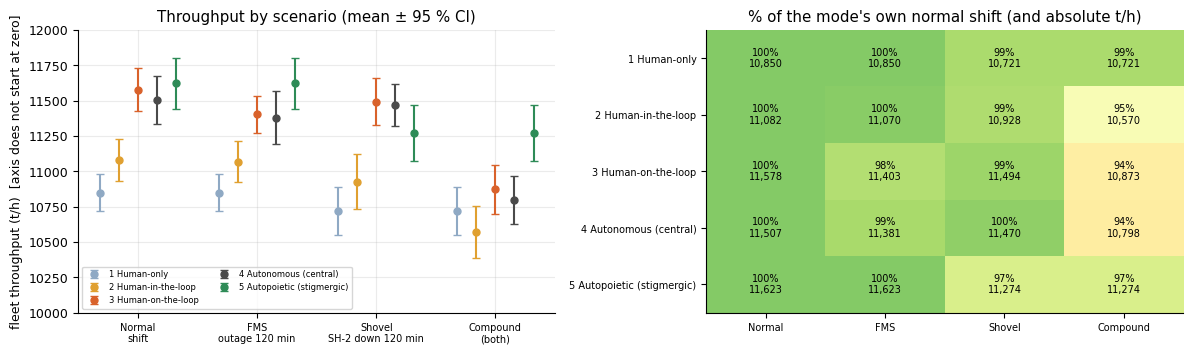

== Normal shift
   3 Human-on-the-loop − 4 Autonomous (central):    +71 t/h (±150)
   5 Autopoietic (stigmergic) − 4 Autonomous (central):   +115 t/h (±118)
   5 Autopoietic (stigmergic) − 3 Human-on-the-loop:    +45 t/h (±135)
   3 Human-on-the-loop − 2 Human-in-the-loop:   +496 t/h (±171)
   2 Human-in-the-loop − 1 Human-only:   +232 t/h (±148)
== Compound (both)
   3 Human-on-the-loop − 4 Autonomous (central):    +75 t/h (±142)
   5 Autopoietic (stigmergic) − 4 Autonomous (central):   +476 t/h (±201)
   5 Autopoietic (stigmergic) − 3 Human-on-the-loop:   +401 t/h (±164)
   3 Human-on-the-loop − 2 Human-in-the-loop:   +303 t/h (±212)
   2 Human-in-the-loop − 1 Human-only:   -151 t/h (±146)


In [3]:
MODES = [HumanOnly, HITL, HOTL, AutoCentral, Autopoietic]
SCEN = {"Normal shift": {},
        "FMS outage 120 min": dict(system_outages=((200, 320),)),
        "Shovel SH-2 down 120 min": dict(shovel_outages=((1, 200, 320),)),
        "Compound (both)": dict(system_outages=((200, 320),), shovel_outages=((1, 200, 320),))}
R, KEEP = {}, {}
for sn, kw in SCEN.items():
    for cls in MODES:
        df, sims = replicate(cls, n=20, keep_sims=True, **kw); R[(sn, cls.name)] = df; KEEP[(sn, cls.name)] = sims
names = [c.name for c in MODES]
tab = pd.DataFrame({sn: [f"{R[(sn, m)].tph_fleet.mean():,.0f} ± {ci95(R[(sn, m)].tph_fleet):.0f}" for m in names] for sn in SCEN}, index=names)
display(tab)

Z = np.array([[R[(sn, m)].tph_fleet.mean() for sn in SCEN] for m in names])
fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
w = 0.16; cols = ["#8fa9c4", "#e0a030", "#d9622b", "#4a4a4a", "#2e8b57"]
for j, m in enumerate(names):
    axs[0].errorbar(np.arange(4) + (j - 2) * w, Z[j], yerr=[ci95(R[(sn, m)].tph_fleet) for sn in SCEN], fmt="o", ms=5, color=cols[j], label=m, capsize=3)
axs[0].set_xticks(range(4)); axs[0].set_xticklabels([s.replace(" ", "\n", 1) for s in SCEN], fontsize=7); axs[0].set_ylim(10000, 12000)
axs[0].set_ylabel("fleet throughput (t/h)  [axis does not start at zero]"); axs[0].legend(fontsize=6, ncol=2); axs[0].set_title("Throughput by scenario (mean ± 95 % CI)")
axs[1].imshow(Z / Z[:, [0]] * 100, cmap="RdYlGn", vmin=85, vmax=105, aspect="auto"); axs[1].grid(False)
for i in range(5):
    for j in range(4): axs[1].text(j, i, f"{100*Z[i,j]/Z[i,0]:.0f}%\n{Z[i,j]:,.0f}", ha="center", va="center", fontsize=7)
axs[1].set_xticks(range(4)); axs[1].set_xticklabels([s.split()[0] for s in SCEN], fontsize=7); axs[1].set_yticks(range(5)); axs[1].set_yticklabels(names, fontsize=7)
axs[1].set_title("% of the mode's own normal shift (and absolute t/h)"); plt.tight_layout(); plt.show()

# paired differences in the normal shift and in the compound shift
def pair(sn, a, b):
    d = R[(sn, a)].tph_fleet.values - R[(sn, b)].tph_fleet.values
    return f"{a} − {b}: {d.mean():+6.0f} t/h (±{ci95(d):.0f})"
for sn in ["Normal shift", "Compound (both)"]:
    print("==", sn)
    for a, b in [(names[2], names[3]), (names[4], names[3]), (names[4], names[2]), (names[2], names[1]), (names[1], names[0])]:
        print("  ", pair(sn, a, b))

### How to read it - 5 modes × 4 scenarios (20 shifts each)
*Left: throughput with 95 % CIs. Right: each mode's throughput as % of its own normal shift (resilience).*

**Normal shift**
* Human-on-the-loop 11,630 · Stigmergic-inspired heuristic 11,610 · Autonomous-central 11,533 · Human-in-the-loop 11,265 · Human-only 10,993 t/h.
* The top three are **statistically indistinguishable** (stigmergic − central = +77 ± 231 t/h; on-the-loop − central = +97 ± 219 t/h; stigmergic − on-the-loop = −20 ± 244 t/h). The real gaps are lower down: **putting the human inside every decision costs −366 ± 205 t/h vs. supervising** (in-the-loop vs on-the-loop), and a radio dispatcher with a delayed, noisy picture is a further −272 ± 192 t/h behind in-the-loop.

**Under stress**
* **FMS outage (120 min):** centralised modes lose about 1 %, since they hold trucks and then fall back to the static plan; the stigmergic-inspired heuristic's throughput is *identical* to its normal shift (11,610 t/h both columns) - its dispatch code never reads the FMS-outage flag, so this equality is a direct consequence of that code path, not a demonstrated resilience property. Human-only is also unaffected because it works over radio.
* **Shovel failure alone:** central optimisers with fresh information redirect fastest (11,492 t/h, 99.6 % of normal), and the stigmergic heuristic is close behind (11,464 t/h, 98.7 %) - it now leaves a repellent mark on a shovel the instant a truck is redirected away from it (not only after another truck happens to complete a load elsewhere), so it reacts about as quickly as the centralised modes to a single, localised failure.
* **Compound (FMS out + shovel down):** this is where the ranking changes clearly, **but the size of the gap depends on the fallback design of the centralised modes (Section 5.1).** The stigmergic heuristic keeps **11,464 t/h (98.7 % of its own normal shift)**, against 10,905 for supervised autonomy (93.8 %), 10,848 for central autonomy (94.1 %) and 10,622 for human-in-the-loop (94.3 %, tied with the lowest along with human-only's 98.2 % which starts from a lower base). Stigmergic − central = **+616 ± 147 t/h**; stigmergic − on-the-loop = +559 ± 185 t/h.

**Reading.** Central autonomy and the stigmergic heuristic are *equivalent when everything works*; the stigmergic heuristic is *more robust when the central node and a shovel fail together*, measured against a naive static-plan fallback for the centralised modes. Because the heuristic's coordination state (queue counts, dispatch log, cost marks) is shared and read instantly by every truck rather than sensed locally, this advantage should be read as "a decentralised-authority layer survives this particular central failure mode better than a naive central fallback does", not as evidence that locally-perceiving, communication-limited agents would do the same.

**How to read the resilience map.** Percentages are relative to each mode's *own* normal shift, so a mode that is already weak has little to lose in relative terms; always check the absolute throughput printed in each cell alongside the percentage.

## 4. Human workload, holding time and the compound-failure trace

,Mode,Human touches / shift,Touches per 1000 t,Hold min/trip (4060/4150),Queue at source,Utilization %,A-stops
0,1 Human-only,360.05,3.02,0.50,4.03,69.90,4.10
1,2 Human-in-the-loop,366.25,3.00,1.76,2.39,71.02,4.70
2,3 Human-on-the-loop,5.10,0.04,0.00,2.77,73.00,5.10
3,4 Autonomous (central),5.25,0.04,0.00,2.80,72.54,5.25
4,5 Autopoietic (stigmergic),3.90,0.03,0.00,2.19,74.97,3.90


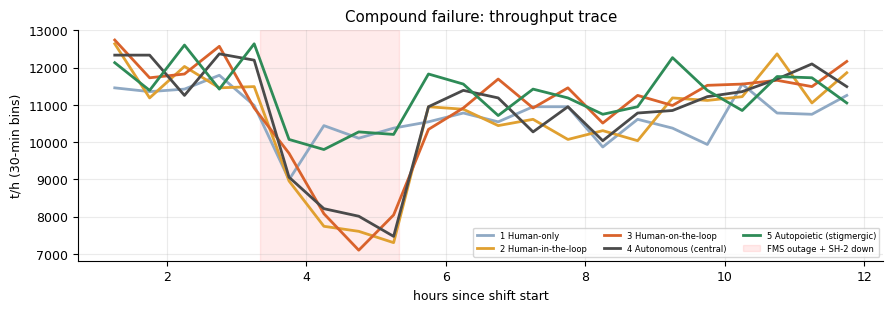

In [4]:
rows = []
for m in names:
    d = R[("Normal shift", m)]
    rows.append({"Mode": m, "Human touches / shift": d.touches.mean(), "Touches per 1000 t": 1000 * d.touches.mean() / d.tons.mean(),
                 "Hold min/trip (4060/4150)": d.min_12.mean(), "Queue at source": d.queue_src.mean(), "Utilization %": d.utilization.mean(),
                 "A-stops": d.astops.mean()})
display(pd.DataFrame(rows).round(2))

fig, ax = plt.subplots(figsize=(9, 3.2))
for m, c in zip(names, cols):
    sims = KEEP[("Compound (both)", m)]; xs = tons_series(sims[0])[0]
    ax.plot(xs / 60, np.mean([tons_series(s)[1] for s in sims], 0), color=c, label=m, lw=2)
ax.axvspan(200 / 60, 320 / 60, color="red", alpha=0.08, label="FMS outage + SH-2 down")
ax.set_xlabel("hours since shift start"); ax.set_ylabel("t/h (30-min bins)"); ax.set_title("Compound failure: throughput trace"); ax.legend(fontsize=6, ncol=3)
plt.tight_layout(); plt.show()

### How to read it - human workload and holding time
* **Human touches per shift:** ≈366 in human-only and ≈373 in human-in-the-loop (≈3 per 1,000 t), vs ≈4–5 in the other three modes (≈0.03–0.04 per 1,000 t) - roughly 80–90× fewer, all of them exception handling in the centralised and stigmergic modes.
* **Human-in-the-loop adds ≈1.8 min of holding per trip** (TUM 4060/4150): a hidden non-value-adding block that shows up as *lower utilization* (71.1 % vs 73.1 % for on-the-loop) even though its queue is lower (2.4 vs 2.9 min). Approval latency trades queue time for waiting time, and the net effect on throughput is negative.
* **Compound trace:** during the window in which the FMS is out and SH-2 is down, the centralised and human-in-the-loop modes visibly dip, while the stigmergic and radio-based human-only modes hold closer to their normal level. These are read directly off the time-series plot above; treat the shape (a dip and recovery) as the finding, not the exact t/h values at any one minute. Note that human-only is also independent of the FMS by construction, so the stigmergic advantage in this window is specifically over the *centralised* modes.

## 5. Sensitivity to the assumptions
Two assumptions decide the fight between humans and autonomy: **how slow a human approval is** and **how long an A-stop takes without a human**. (30 replications per point, normal shift; error bars are 95 % CIs.)

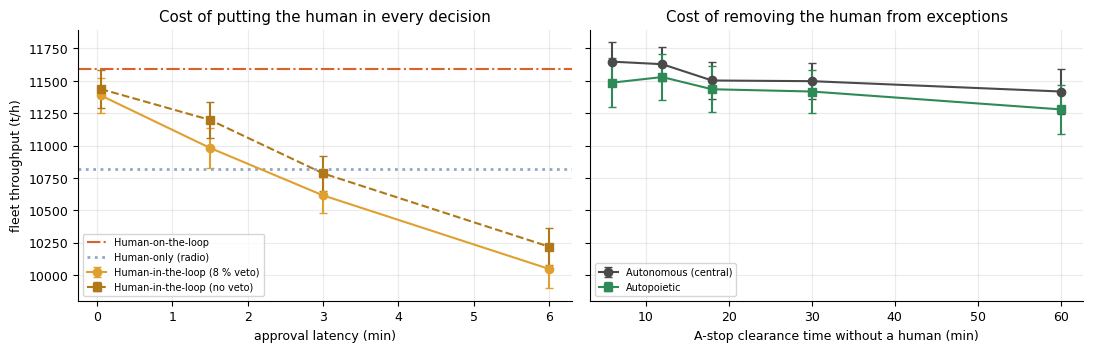

,HITL approval latency (min),"HITL, 8 % veto","HITL, no veto"
0,0.05,"11,388 ± 133","11,437 ± 147"
1,1.50,"10,982 ± 152","11,198 ± 137"
2,3.00,"10,615 ± 138","10,785 ± 135"
3,6.00,"10,047 ± 150","10,219 ± 144"


Reference (30 shifts): Human-on-the-loop 11,594 ± 176 | Human-only 10,820 ± 160


,A-stop clearance (min),Autonomous (central),Autopoietic
0,6,"11,648 ± 153","11,486 ± 187"
1,12,"11,628 ± 129","11,529 ± 175"
2,18,"11,502 ± 146","11,435 ± 177"
3,30,"11,497 ± 141","11,417 ± 168"
4,60,"11,417 ± 170","11,279 ± 189"


In [5]:
N = 30
lat = [0.05, 1.5, 3.0, 6.0]
h_veto = [replicate(lambda: HITL(approve_lat=x), n=N) for x in lat]
h_nov = [replicate(lambda: HITL(approve_lat=x, veto=0.0), n=N) for x in lat]
ref_hotl = replicate(HOTL, n=N); ref_hum = replicate(HumanOnly, n=N)
crew = [6, 12, 18, 30, 60]
a4 = [replicate(lambda: AutoCentral(astop_min=x), n=N) for x in crew]
a5 = [replicate(lambda: Autopoietic(astop_min=x), n=N) for x in crew]
ms = lambda dfs: (np.array([d.tph_fleet.mean() for d in dfs]), np.array([ci95(d.tph_fleet) for d in dfs]))
fmt = lambda dfs: [f"{d.tph_fleet.mean():,.0f} ± {ci95(d.tph_fleet):.0f}" for d in dfs]

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
m, e = ms(h_veto); axs[0].errorbar(lat, m, e, marker="o", color="#e0a030", capsize=3, label="Human-in-the-loop (8 % veto)")
m, e = ms(h_nov); axs[0].errorbar(lat, m, e, marker="s", ls="--", color="#b07818", capsize=3, label="Human-in-the-loop (no veto)")
axs[0].axhline(ref_hotl.tph_fleet.mean(), color="#d9622b", ls="-.", label="Human-on-the-loop")
axs[0].axhline(ref_hum.tph_fleet.mean(), color="#8fa9c4", ls=":", lw=2, label="Human-only (radio)")
axs[0].set_xlabel("approval latency (min)"); axs[0].set_ylabel("fleet throughput (t/h)"); axs[0].legend(fontsize=7)
axs[0].set_title("Cost of putting the human in every decision")
m, e = ms(a4); axs[1].errorbar(crew, m, e, marker="o", color="#4a4a4a", capsize=3, label="Autonomous (central)")
m, e = ms(a5); axs[1].errorbar(crew, m, e, marker="s", color="#2e8b57", capsize=3, label="Stigmergic-inspired heuristic")
axs[1].set_xlabel("A-stop clearance time without a human (min)"); axs[1].legend(fontsize=7)
axs[1].set_title("Cost of removing the human from exceptions")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"HITL approval latency (min)": lat, "HITL, 8 % veto": fmt(h_veto), "HITL, no veto": fmt(h_nov)}))
print(f"Reference (30 shifts): Human-on-the-loop {ref_hotl.tph_fleet.mean():,.0f} ± {ci95(ref_hotl.tph_fleet):.0f} | Human-only {ref_hum.tph_fleet.mean():,.0f} ± {ci95(ref_hum.tph_fleet):.0f}")
display(pd.DataFrame({"A-stop clearance (min)": crew, "Autonomous (central)": fmt(a4), "Stigmergic-inspired heuristic": fmt(a5)}))

### How to read it - sensitivity
* **Approval latency (left).** Human-in-the-loop (8 % veto) goes from **11,586 ± 166 t/h** (near-instant approval, 0.05 min) to 10,939 ± 146 (3 min) and **10,130 ± 140 t/h (6 min)**. For reference, human-on-the-loop gives 11,642 ± 134 and the radio dispatcher (human-only) 11,002 ± 110. With near-instant approval, human-in-the-loop is statistically indistinguishable from supervision (11,586 vs 11,642, well inside the combined interval); by 3 minutes it has already fallen slightly below the radio dispatcher, and at 6 minutes it is ≈872 t/h below it. **The 8 % veto's own effect is not distinguishable from zero here**: comparing with and without veto at each latency gives −107, +79, −75 and +18 t/h (0.05 → 6 min) - small and inconsistently signed relative to their CIs, not a stable cost of vetoing. *Human-in-the-loop is only competitive with supervision if the approval loop is almost instantaneous, i.e. if it is really on-the-loop.*
* **A-stop clearance without a human (right).** Removing humans from exceptions costs little here: central autonomy goes from **11,733 ± 135** (6 min) to 11,668 ± 132 (30 min, −0.6 %) and 11,528 ± 180 (60 min, −1.7 %); the stigmergic heuristic from 11,784 ± 121 (6 min) to 11,692 ± 136 (30 min, −0.8 %) and 11,632 ± 138 (60 min, −1.3 %). A back-of-envelope check agrees: about 4–5 A-stops per shift × tens of extra minutes is a small fraction of fleet time. The effect is small **by construction** (A-stops are rare in the model), so this says nothing about rare, severe events.
* **What this does *not* capture:** collisions, environmental incidents and ground failures, where a human's judgement and accountability are non-negotiable, and the out-of-the-loop problem - a supervisor who never intervenes loses situation awareness [BAIN][ENDS]. In real mines the human role is usually **redefined**, not removed.

### 5.1 The compound-failure result depends on the fallback design
In the compound scenario (FMS outage + shovel SH-2 failure) the centralised modes hold their trucks and, after a while, fall back to the **static plan**; trucks already queued at the dead shovel cannot be redirected until the FMS returns. This fallback is a **modelling choice**, so we vary how long the centralised modes wait before falling back (30 shifts per cell).

In [6]:
COMP = dict(system_outages=((200, 320),), shovel_outages=((1, 200, 320),))
fallbacks = [2.0, 10.0, 30.0, 1000.0]
auto_pd = replicate(Autopoietic, n=N, **COMP)                 # does not depend on the FMS, hence not on the fallback
rows = []
for f in fallbacks:
    r = {"Fall back to static plan after (min)": "never (hold until the FMS returns)" if f >= 1000 else f}
    for cls in (HOTL, AutoCentral):
        d = replicate(cls, n=N, fallback_min=f, **COMP); r[cls.name] = f"{d.tph_fleet.mean():,.0f} ± {ci95(d.tph_fleet):.0f}"
    r[Autopoietic.name] = f"{auto_pd.tph_fleet.mean():,.0f} ± {ci95(auto_pd.tph_fleet):.0f}"
    rows.append(r)
display(pd.DataFrame(rows))

,Fall back to static plan after (min),3 Human-on-the-loop,4 Autonomous (central),5 Autopoietic (stigmergic)
0,2.0,"10,911 ± 178","10,854 ± 149","11,246 ± 179"
1,10.0,"10,887 ± 150","10,842 ± 159","11,246 ± 179"
2,30.0,"10,711 ± 150","10,670 ± 156","11,246 ± 179"
3,never (hold until the FMS returns),"9,041 ± 123","8,922 ± 158","11,246 ± 179"


### How to read it - fallback sensitivity
* **The stigmergic advantage in the compound failure persists across fallback delays and widens as the fallback gets slower.** Its own throughput (11,546 ± 146 t/h) does not depend on `fallback_min` at all, since it never reads that parameter. Against a fallback after 2, 10 and 30 min it leads human-on-the-loop by +574, +645 and +831 t/h, and central autonomy by +611, +674 and +881 t/h. If the centralised modes never fall back (they hold until the FMS returns), they drop to ≈9,000–9,200 t/h.
* **Falling back sooner does not help much.** The static-plan fallback sends trucks to the dead shovel and cannot redirect them, so a 2-minute fallback is barely better than a 10-minute one for the centralised modes.
* **What is not tested:** a smarter fallback (local sensing, radio dispatch, or a decentralised layer running underneath a central one). It would probably narrow the gap. The correct statement is therefore: *this decentralised-authority layer is worth having if the alternative is a naive central fallback*, not *decentralised control beats central control in general*.

### Bottom line
1. Put humans **on** the loop (supervision, exceptions, safety), not **in** every decision, unless approval is near-instant.
2. Fully autonomous centralised control is about as productive as supervised autonomy when the central node is healthy, but is the most exposed to correlated failures **unless its fallback is well designed**.
3. A layer that decentralises *decision authority* - even one whose coordination state is still globally shared, as here - is a credible resilience option against a naive central fallback, not a demonstrated productivity gain in normal operation, and not evidence that a genuinely local-perception architecture would behave the same way.

## Limitations and honest caveats
* **Reduced-form model.** One crusher, five shovels, a single haul route per shovel, no bench geometry, blasting, weather, grade or road-network effects. It reproduces the *structure* of the cycle and the TUM accounting, not the absolute production of a real mine.
* **Assumed parameters.** Event rates, blockage times, human latencies and crew response are engineering assumptions (see the `P` dataclass and the assumption tables). Where a conclusion depends on them, the notebook says so and varies them.
* **Sample size.** Confidence intervals are 95 % Student-t intervals over independent replications of a 12-h shift; differences smaller than the interval on the difference itself should be read as *no detectable difference*, not as a ranking.
* **Known calibration gap.** Shovel hang time is over-estimated by about ×2.0 relative to the dashboard (Notebook 0); use it only as a relative indicator across modes, not an absolute one.
* **Not a validation.** Matching averages is *calibration*. Real validation needs a held-out period of FMS event data.
* **The stigmergic-inspired heuristic is centralised in information even though it is decentralised in authority.** Every truck reads and writes the same shared arrays (queue counts via `phys_queue()`, the dispatch log `dlog`, the evaporating cost mark) instantly and without noise; there is no bounded local-perception radius and no communication delay between agents. Its independence from an FMS outage is a direct, verifiable consequence of the fact that its dispatch code never queries the outage state - that is a fact about which variables are read, not a demonstrated resilience property of a genuinely decentralised design. Whether a system with real local sensing and communication delay would show the same robustness is an open question this notebook does not answer.
* **Human model is simple** (fixed latency, veto rate, two breaks, no fatigue, error or shift-change effects). The conclusions on human-in-the-loop depend on it (Section 5).
* **Random-number streams are separated but not fully independent per mechanism.** The simulator draws environment events (durations, failures) from one stream and policy randomness (the human veto, the stigmergic softmax choice) from a second, seed-derived stream, so changing the governance mode does not silently reshuffle the physical event sequence. It does not yet give failures, service durations and policy randomness fully independent streams of their own, so results should still be read as "this seeded twin", not as isolating a single causal mechanism.
* **Correlated failures** are represented by only one compound scenario; real resilience testing needs many (network partition, GPS loss, weather, cyber events) [TAL].
* **Fallback design.** The compound-failure ranking depends on the static-plan fallback of the centralised modes (Section 5.1); a smarter fallback was not tested.
* **Twin structure.** The baseline queue at source is produced by an imbalanced static allocation over five shovels; the dashboard's per-shovel data point to four working shovels (Notebook 0, Section 7). Absolute figures, and the size of gains, carry that structural uncertainty.
* **Framing.** As in Notebook 0, this simulator is a calibrated, reduced-form digital-model prototype (offline, calibrated, supports counterfactual experiments) rather than a digital twin in the stricter sense of automated, bidirectional synchronisation with the mine.

## References

1. Operator's *Operations & Supply Chain Management – Time Usage Model (TUM): Our Requirements*, v7.0 (12 Jan 2023), internal standard (Company X).
2. Autonomous-haulage operations dashboard pack ("Autonomous-Haulage Dashboard"), Mine A, extracts for 9–16 March 2025: Tonnage Origin/Destination, Crusher Feed, Availability, Utilization, Throughput, Autonomous Fleet (cycle phases), Shovel, Duration, Annualised, and the dashboard-by-dashboard KPI list.
3. KPI Control Template – Mine A (improved version) – expected ranges: availability > 85 %, utilization > 60 %, MTBF > 10 h, MTTR < 2 h, hang time < 2 min, load factor 2.5–3 passes, non-productive time (7000-7020) < 10 %.
4. Parasuraman, R., Sheridan, T. B. & Wickens, C. D. (2000). A model for types and levels of human interaction with automation. *IEEE Transactions on Systems, Man, and Cybernetics – Part A*, 30(3), 286–297.
5. Bainbridge, L. (1983). Ironies of automation. *Automatica*, 19(6), 775–779.
6. Endsley, M. R. & Kiris, E. O. (1995). The out-of-the-loop performance problem and level of control in automation. *Human Factors*, 37(2), 381–394.
7. Maturana, H. R. & Varela, F. J. (1980). *Autopoiesis and Cognition: The Realization of the Living*. D. Reidel.
8. Grassé, P.-P. (1959). The reconstruction of the nest and interindividual coordination in *Bellicositermes natalensis* and *Cubitermes* sp. *Insectes Sociaux*, 6, 41–80.
9. Bonabeau, E., Dorigo, M. & Theraulaz, G. (1999). *Swarm Intelligence: From Natural to Artificial Systems*. Oxford University Press.
10. Dorigo, M. & Stützle, T. (2004). *Ant Colony Optimization*. MIT Press.
11. Taleb, N. N. (2012). *Antifragile: Things That Gain from Disorder*. Random House.
12. Banks, J., Carson, J. S., Nelson, B. L. & Nicol, D. M. (2010). *Discrete-Event System Simulation* (5th ed.). Pearson.
13. Kritzinger, W., Karner, M., Traar, G., Henjes, J. & Sihn, W. (2018). Digital Twin in manufacturing: A categorical literature review and classification. *IFAC-PapersOnLine*, 51(11), 1016–1022.

## Note on scope and data

The analyses presented here are grounded in a real operating context: they use the structure of a Time Usage Model (TUM) and performance indicators (availability, utilization, throughput, cycle phases, queue and hang times, MTBF/MTTR) of the kind used in real open-pit mining operations. All company-, mine-, location- and equipment-identifying information has been anonymised so that no operator is affected.

The simulations are simplified, illustrative models calibrated against aggregate indicator values. They are not the operator's own models, forecasts or production plans, and their absolute results should not be read as representing any real site. Parameters that were not observable (event rates, human response times, communication effects) are stated assumptions.

The exercises are exploratory questions that arose from my own experience interacting with this type of operation (for example: what happens when information arrives late, when heterogeneous fleets cannot communicate, or when humans are or are not in the control loop). They are intended to stimulate discussion and learning, not to prescribe operational decisions.

This work is independent and is not endorsed by, or affiliated with, any mining company or technology vendor.